## Exercise Project 1 -- Linear Regression
### Dataset: [NYC Housing Prices](https://www.kaggle.com/datasets/ishank2005/nyc-housing-prices-csv)

<br>
<br>


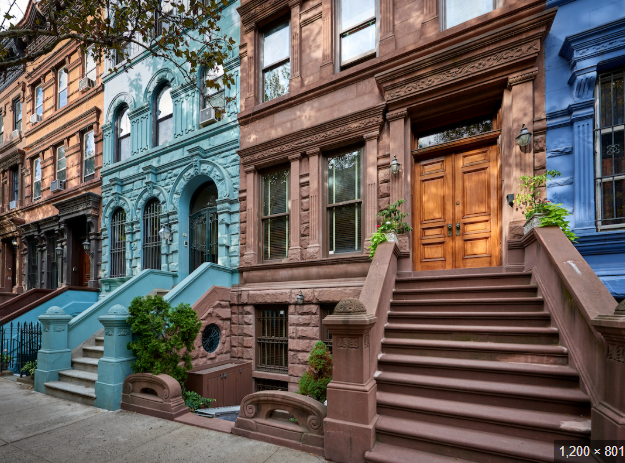

<br>

<br>

##### Shape: `34k rows, 19 columns`

##### Target Variable: `sale_price`

##### Method: `Linear Regression`

##### Extra Tools: `Mlflow`

##### Column Descriptions (Complete):

| Column        | Description |
|--------------|-------------|
| borough_x    | *Borough code associated with the property sale record, sourced from the NYC Citywide Rolling Sales dataset.* |
| block        | *NYC tax block identifier for the property, used as part of the Borough–Block–Lot (BBL) system.* |
| lot          | *NYC tax lot identifier for the property, used as part of the Borough–Block–Lot (BBL) system.* |
| sale_price   | *Recorded sale price of the property transaction in US dollars. Non-arm’s-length and invalid transactions have been removed.* |
| zip_code     | *ZIP code of the property as recorded in the sales transaction data.* |
| borough_y    | *Borough code associated with the property tax lot, sourced from the PLUTO building dataset.* |
| yearbuilt    | *Year in which the primary structure on the tax lot was originally constructed.* |
| lotarea      | *Total land area of the tax lot, measured in square feet.* |
| bldgarea     | *Total gross building floor area on the tax lot, measured in square feet.* |
| resarea      | *Portion of the building floor area used for residential purposes, measured in square feet.* |
| comarea      | *Total commercial floor area within the building, measured in square feet.* |
| unitsres     | *Number of residential housing units on the tax lot.* |
| unitstotal   | *Total number of units on the tax lot, including residential and non-residential units.* |
| numfloors    | *Number of floors in the primary building on the tax lot.* |
| latitude     | *Latitude coordinate of the property location, expressed in decimal degrees.* |
| longitude    | *Longitude coordinate of the property location, expressed in decimal degrees.* |
| landuse      | *Numeric land use category code describing the primary use of the property (e.g., residential, commercial, mixed-use).* |
| bldgclass    | *NYC building class code indicating the structural and usage classification of the property.* |
| building_age | *Age of the building in years at the time of sale, calculated as sale year minus year built.* |


<br>
<br>



---

### Code

In [18]:
# import 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.preprocessing import OneHotEncoder
import mlflow

# Reading the dataframe and storing it.
df = pd.read_csv("datasets/nyc_housing.csv")
df.head(5)

,borough_x,block,lot,sale_price,zip_code,borough_y,yearbuilt,lotarea,bldgarea,resarea,comarea,unitsres,unitstotal,numfloors,latitude,longitude,landuse,bldgclass,building_age
0,1,400,11,280000,10009.0,MN,1900.0,2404.0,6875.0,6875.0,0.0,18.0,18.0,5.0,40.724415,-73.983891,2.0,C6,125.0
1,1,402,36,2000000,10009.0,MN,1900.0,1919.0,7810.0,6810.0,1000.0,8.0,10.0,5.0,40.724975,-73.981535,2.0,C4,125.0
2,1,402,60,3400000,10009.0,MN,1920.0,2150.0,6152.0,5352.0,800.0,8.0,9.0,5.0,40.725346,-73.983112,4.0,C7,105.0
3,1,404,42,4000000,10009.0,MN,1855.0,2369.0,6990.0,6990.0,0.0,10.0,10.0,5.0,40.727398,-73.980600,2.0,C4,170.0
4,1,372,55,655000,10009.0,MN,1920.0,5298.0,17990.0,17990.0,0.0,20.0,20.0,5.0,40.720621,-73.979534,2.0,C6,105.0


## Cleaning

|Step|Description|
|---|---|
|1|<bold style="background:yellow;color:black;"> Data Cleaning </bold>|
|2| Transformation|
|3| ML Training & Metrics|
|4|Tester Row Values|
|5| Personal Analysis |
|6|GUI Application|
|7| Advanced Tasks|

The cleaning process will consist of the following:
<i>
1. Handling missing values
2. Handling duplicates
3. Dropping multi-colinearity (co-cardinality) features
4. Turning Features into numbers (if needed)
</i>

#### Checking The Dataframe Shape

In [19]:
# Checking the amount of columns and rows.
df.shape

# That seems like a reasonable amount of data. Lots to work with.

(34439, 19)

#### Handling Missing Values

In [20]:
# Checking for missing values
df.isna().sum()

# A small amount of rows have missing values. 
# Getting rid of all the NaN will be trivial 200/34000 = .5% of the data. Not timeseries, so it's fine.

borough_x         0
block             0
lot               0
sale_price        0
zip_code         16
borough_y         0
yearbuilt         0
lotarea           0
bldgarea          0
resarea         188
comarea         188
unitsres          0
unitstotal        0
numfloors        43
latitude          6
longitude         6
landuse           3
bldgclass         0
building_age      0
dtype: int64

In [21]:
# Dropping nan values.
df = df.dropna()

#### Handling Duplicates

In [22]:
# Checking for duplicates
df.duplicated().value_counts()

# Some duplicates do exist. We can safely get rid of these.

False    33204
True       999
Name: count, dtype: int64

In [23]:
# Dropping the duplicate rows.
df = df.drop_duplicates()

##### Dropping Columns

Here, we'll be dropping some of the columns which we know we won't be using. I've placed the justifications in as side-comments.




In [24]:
# Dropping co-dependent/high collinearity columns
df = df.drop(["borough_x",       # Related to borough_y
                'latitude',      # Probably just noise in the data.
                'longitude',     # Probably just noise in the data.
                'yearbuilt',     # This is co-dependent with `buildingage`
                'comarea',       # In this dataset: bldgarea = comarea + resarea. co-dependent.
                'resarea',       # In this dataset: bldgarea = comarea + resarea. co-dependent.
                'lot',           # We have borough_y. This is too specific, you'd have distributions of 1 unit being in lot ABC, hardly statistical.
                'block',         # We have borough_y, too specific. We cant have 3 units in a block be a statistical weight for an ML model.
                'zip_code',      # Too specific, it'll affect distribution.
                'landuse',       # This is often co-dependent with bldgclass (D4 bldgclass = landuse 3 for example).      
], axis=1)

# `borough_y` and `bldglclass` is categorical, we'll convert this to numbers. 
df.head(3)


,sale_price,borough_y,lotarea,bldgarea,unitsres,unitstotal,numfloors,bldgclass,building_age
0,280000,MN,2404.0,6875.0,18.0,18.0,5.0,C6,125.0
1,2000000,MN,1919.0,7810.0,8.0,10.0,5.0,C4,125.0
2,3400000,MN,2150.0,6152.0,8.0,9.0,5.0,C7,105.0


##### Categorical Feature Isolated Case Elimination

Any categorical features we create might sometimes create too many cases.

That's a problem because each of these categories will be a bucket, which takes it's own weight value for the `Salary`. I like to describe this situation like _putting a five-hundred euro bet by asking ONE person on the side of the road which team would win the Superbowl._ Naturally, that's not very statistical. So, let's look at all of these categorical variables more closely.

##### `bldgclass`

In [25]:
# In `bldgclass`, there are isolated cases there just isn't enough data
# to give a fair statistical weight to them.
value_counts = df['bldgclass'].value_counts().sort_values(ascending=True)
value_counts
# We need to get rid of some of these isolated cases.

bldgclass
I7       1
H8       1
I4       1
P7       1
P3       1
      ... 
B2    2523
B1    2613
A5    3314
A1    4037
D4    6079
Name: count, Length: 109, dtype: int64

In [26]:
# This eliminates any building classes that have less than 20 values. 
df = df[df['bldgclass'].isin(value_counts[value_counts >= 20].index)]

# REASONING:
# For example: What if `bldgclass` has only one `G7` row value and also that it was an unusual, extreme case that did not fit
# the real world well, what would happen?

# Well, now I'm empowering that one-particular case with it's own column and inaccurate
# weight value for my ML model. Let's avoid that.

##### `borough_y`

In [27]:
# Let's check the other categorical feature, `borough_y`
df['borough_y'].value_counts()

# This seems ok! plenty of data to work with.

borough_y
QN    12619
BK     9532
SI     3842
MN     3717
BX     3221
Name: count, dtype: int64

##### Turning Categorical Columns into Numbers

This turns the categorical column into separate binary columns for each case.

In [28]:
# List of columns to convert to numbers.
categorical_columns = ["borough_y",  # Example values: MN, ME, BK
                       "bldgclass",  # Example values: C6, K4, C8
                       ]


# Converts columns into binary, separate columns.
for column in categorical_columns:
    encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
    one_hot_encoded = encoder.fit_transform(df[[column]]).astype(int)
    df = pd.concat([df.drop(columns=[column]), one_hot_encoded], axis=1)

---



### Transformation

|Step|Description|
|---|---|
|1| Data Cleaning |
|2|<bold style="background:yellow;color:black;"> Transformation </bold>|
|3| ML Training & Metrics|
|4| Tester Row Values|
|5| Personal Analysis |
|6| GUI Application|
|7| Advanced Tasks|


####  Target Outlier & Skew Elimination

Here, we're taking a look at what the target variable's skew will look like. My approach will be to show a 'before' and 'after' histplot, where whoever is reading this can see precisely what changes have been made and what the results look like.

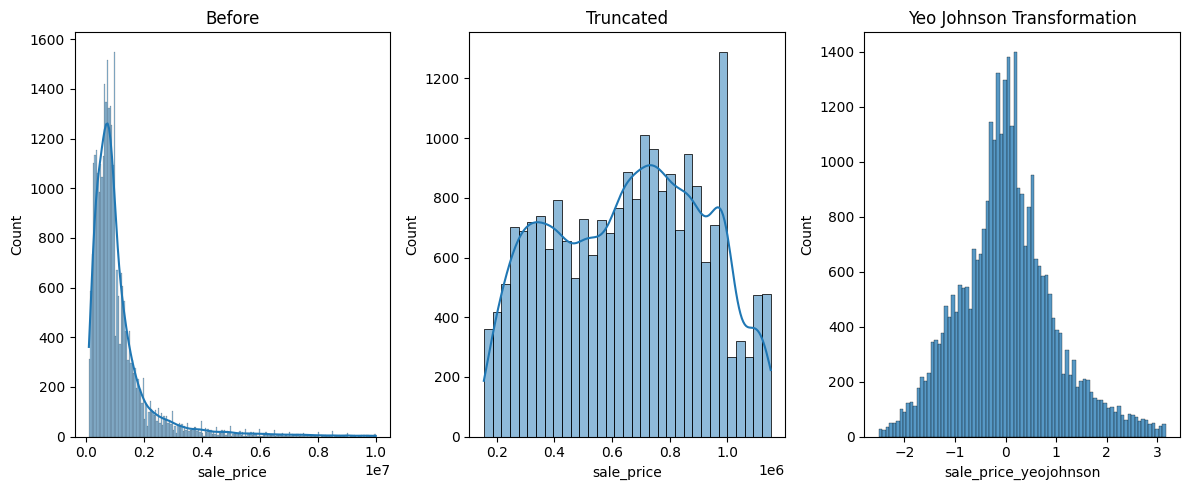

Rows left: 32602


In [29]:
from sklearn.preprocessing import PowerTransformer

# Target variable cutoffs (these constants show up in MLFLOW to track parameters of the run).
y_trunc_floor = 0.02
y_trunc_ceiling = 0.70

# Creates three canvases for histplots to show my work.
fig, axes = plt.subplots(1, 3, figsize=(12, 5))


# Truncating the Y variable.
df_trunc = df[
    (df['sale_price'] >= df['sale_price'].quantile(q=y_trunc_floor)) &
    (df['sale_price'] <= df['sale_price'].quantile(q=y_trunc_ceiling))
    ]



pt = PowerTransformer(method='yeo-johnson')
df['sale_price_yeojohnson'] = pt.fit_transform(df[['sale_price']])

df = df[df['sale_price_yeojohnson'] >= df["sale_price_yeojohnson"].quantile(.01)]


# Histplots
sns.histplot(df, x='sale_price', ax=axes[0], kde=True)
sns.histplot(df_trunc, x='sale_price', ax=axes[1], kde=True)
sns.histplot(df, x="sale_price_yeojohnson", ax=axes[2])

# Plot titles
axes[0].set_title("Before")
axes[1].set_title("Truncated")
axes[2].set_title("Yeo Johnson Transformation")
plt.tight_layout()
plt.show()

# It's not perfect, but it will do!

# SANITY CHECK:
# Let's check how many rows we have left.
print(f"Rows left: {df.shape[0]}")

<div style="border: 3px dashed white; padding: 10px; box-sizing: border-box;">

<h3>Note</h3>

I have tried so many different transformations and truncation combinations with this target variable, all to no-avail for a better result.

I've tried different methods to reduce the skew, such as: 

* Logarithmic Transformation
* Square, Cube Transformation
* Auto-truncation methods (such as the first method in Tuomas' lecture notes, which eliminates values > 3 stdevs away)
* Many different truncation floor and ceiling parameters.

None of these methods worked as well as this manual trunctation method (both MAE and R^2 were negatively affected). Which is interesting, since the distribution
was remarkably more normal with some of these methods. 


<strong style='color:orange ; background-color:black;'> KISS (Keep it stupid simple), I suppose! </strong>

</div>

#### Pearson Correlation

Since our model will be `LinearRegression`, we'll only be using Pearson correlation to check for features since it is almost a perfect indicator for feature importance


In [30]:
df.head(3)

,sale_price,lotarea,bldgarea,unitsres,unitstotal,numfloors,building_age,borough_y_BK,borough_y_BX,borough_y_MN,...,bldgclass_O5,bldgclass_O7,bldgclass_O8,bldgclass_S1,bldgclass_S2,bldgclass_S3,bldgclass_S4,bldgclass_S5,bldgclass_S9,sale_price_yeojohnson
0,280000,2404.0,6875.0,18.0,18.0,5.0,125.0,0,0,1,...,0,0,0,0,0,0,0,0,0,-1.329775
1,2000000,1919.0,7810.0,8.0,10.0,5.0,125.0,0,0,1,...,0,0,0,0,0,0,0,0,0,1.100819
2,3400000,2150.0,6152.0,8.0,9.0,5.0,105.0,0,0,1,...,0,0,0,0,0,0,0,0,0,1.773400


In [35]:
# First, we create a correlation series for the target variable and all the other features.
# We'll use the absolute value of the correlation here.
correlations = df.corr( method='pearson',numeric_only=True).sort_values(by='sale_price')
correlations = abs(correlations["sale_price"])
correlations.head(12)

# Now, we turn this correlation series into a pandas dataframe
corr_df = pd.DataFrame(correlations).reset_index()

# Renaming the columns to make it tidy.
corr_df = corr_df.rename(columns={
    "index": "Feature",
    "sale_price": "Absolute Correlation Value"
})


# Filtering out `sale_price`, which naturally correlates with itself.
corr_df = corr_df[corr_df["Feature"] != "sale_price"]


# Viola, the most import features.
corr_df

,Feature,Absolute Correlation Value
0,bldgclass_D4,0.152229
1,unitsres,0.115400
2,borough_y_QN,0.114170
3,unitstotal,0.113987
4,bldgclass_C6,0.089357
...,...,...
60,borough_y_BK,0.107511
61,bldgclass_A4,0.114511
62,borough_y_MN,0.119203
63,building_age,0.142252


In [ ]:


# Viola, the most import features.
corr_df

In [36]:
df

,sale_price,lotarea,bldgarea,unitsres,unitstotal,numfloors,building_age,borough_y_BK,borough_y_BX,borough_y_MN,...,bldgclass_O5,bldgclass_O7,bldgclass_O8,bldgclass_S1,bldgclass_S2,bldgclass_S3,bldgclass_S4,bldgclass_S5,bldgclass_S9,sale_price_yeojohnson
0,280000,2404.0,6875.0,18.0,18.0,5.0,125.0,0,0,1,...,0,0,0,0,0,0,0,0,0,-1.329775
1,2000000,1919.0,7810.0,8.0,10.0,5.0,125.0,0,0,1,...,0,0,0,0,0,0,0,0,0,1.100819
2,3400000,2150.0,6152.0,8.0,9.0,5.0,105.0,0,0,1,...,0,0,0,0,0,0,0,0,0,1.773400
3,4000000,2369.0,6990.0,10.0,10.0,5.0,170.0,0,0,1,...,0,0,0,0,0,0,0,0,0,1.980831
4,655000,5298.0,17990.0,20.0,20.0,5.0,105.0,0,0,1,...,0,0,0,0,0,0,0,0,0,-0.290911
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34434,850000,3180.0,1300.0,2.0,2.0,2.0,29.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.031216
34435,855000,3700.0,2500.0,2.0,2.0,3.0,30.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.038485
34436,1200000,4359.0,2200.0,2.0,2.0,2.0,24.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.460067
34437,800000,2185.0,1458.0,1.0,1.0,2.0,75.0,0,0,0,...,0,0,0,0,0,0,0,0,0,-0.043872


Now we have a dataframe of the correlations sorted by the most important features in descending format, we'll now put some of these best features as a list. Our goal will be to call that list as a filter for the `X` split in the model. It'll be called later like this:

`X = df[features_list]`

In [37]:
# This is the list we'll feed into the dataframe filter.
features_list = list(corr_df["Feature"].head(30))
features_list

['bldgclass_D4',
 'unitsres',
 'borough_y_QN',
 'unitstotal',
 'bldgclass_C6',
 'bldgarea',
 'borough_y_BX',
 'bldgclass_A5',
 'bldgclass_A1',
 'lotarea',
 'bldgclass_A2',
 'borough_y_SI',
 'bldgclass_B2',
 'bldgclass_G4',
 'numfloors',
 'bldgclass_A8',
 'bldgclass_A6',
 'bldgclass_A0',
 'bldgclass_A9',
 'bldgclass_B3',
 'bldgclass_D3',
 'bldgclass_M9',
 'bldgclass_O7',
 'bldgclass_S1',
 'bldgclass_G8',
 'bldgclass_D6',
 'bldgclass_F5',
 'bldgclass_M1',
 'bldgclass_O8',
 'bldgclass_B9']

#### Checking for Feature Independence (via Correlation Heatmap)

Our last step for selecting these features is to be sure that these features are independent from one-another. We're going to do this via using a correlation heatmap. We'll only be looking at `X`, meaning the feature candidates that we could be using to predict the target variable `Y`.

<Axes: >

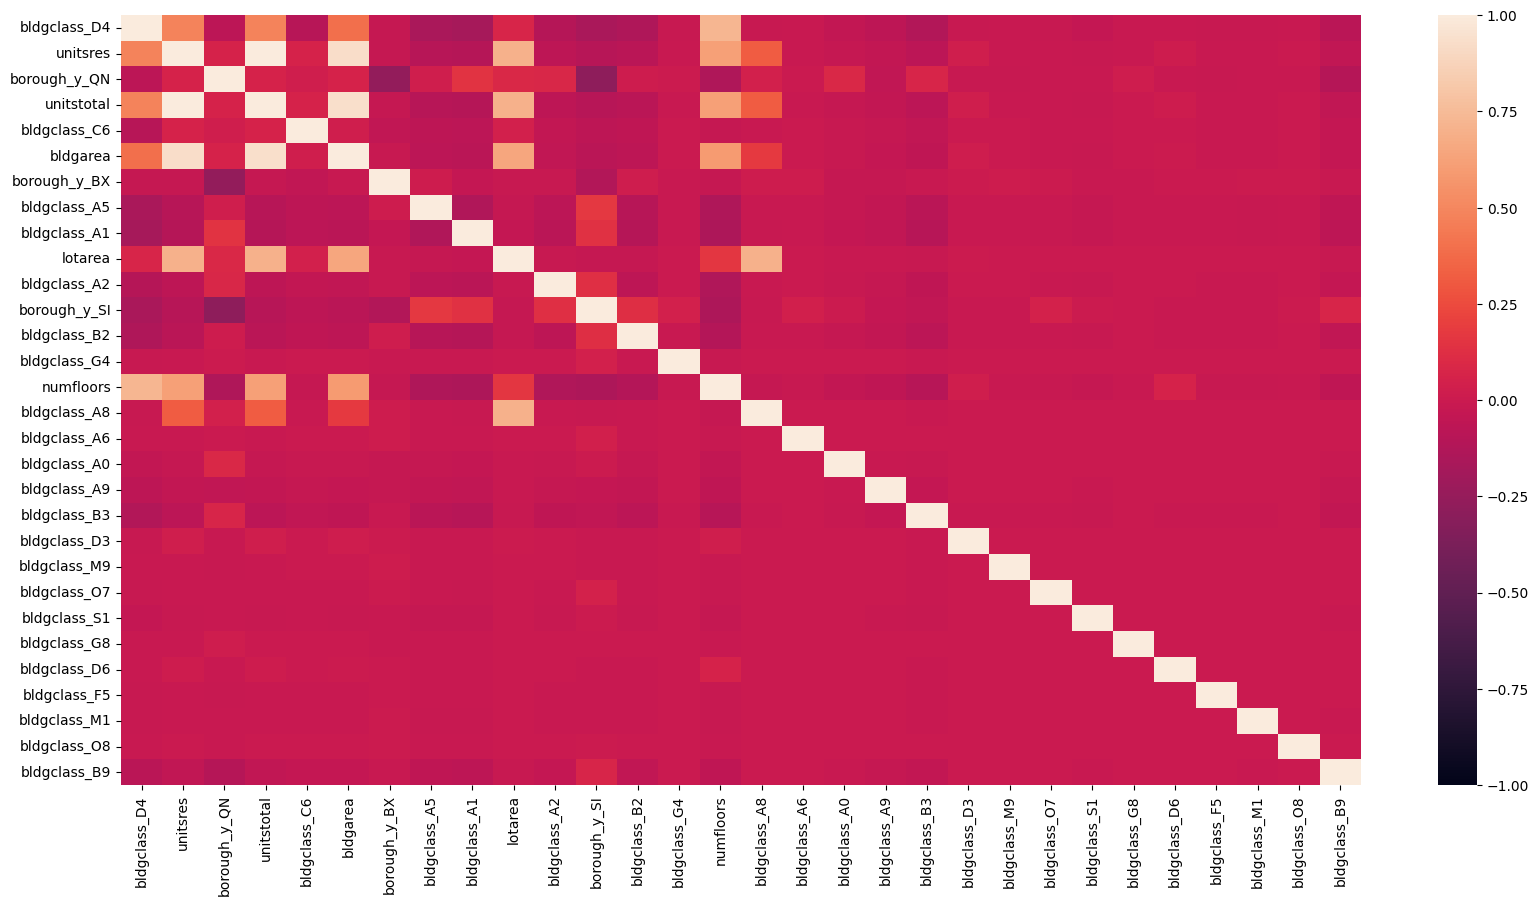

In [38]:
correlation = df[features_list].corr(numeric_only=True)
plt.figure(figsize=(20,10))
sns.heatmap(correlation, vmin=-1, vmax=1)

# I took the annotations out for readability.

#### 

<div style="border: 3px dashed white; padding: 10px; box-sizing: border-box;">

<h3>Observations</h3>

We have a problem, some of these features corrolate way too much with one-another.

|Correlation Value| Feature A | Feature B|
|---|---|---|
|_1.0_|`unitsres`|`unitstotal`|
|_0.93_|`unitsres`|`bldgarea`|
|_0.93_|`unitsres`|`bldgarea`|

This is multi-collinearity and we'll need to get rid of a couple of these features before continuing.


</div>

In [39]:
# Removing these co-dependent features from the features list.
features_list.remove("unitsres")
features_list.remove("unitstotal")
features_list

['bldgclass_D4',
 'borough_y_QN',
 'bldgclass_C6',
 'bldgarea',
 'borough_y_BX',
 'bldgclass_A5',
 'bldgclass_A1',
 'lotarea',
 'bldgclass_A2',
 'borough_y_SI',
 'bldgclass_B2',
 'bldgclass_G4',
 'numfloors',
 'bldgclass_A8',
 'bldgclass_A6',
 'bldgclass_A0',
 'bldgclass_A9',
 'bldgclass_B3',
 'bldgclass_D3',
 'bldgclass_M9',
 'bldgclass_O7',
 'bldgclass_S1',
 'bldgclass_G8',
 'bldgclass_D6',
 'bldgclass_F5',
 'bldgclass_M1',
 'bldgclass_O8',
 'bldgclass_B9']

---

### ML Implementation

|Step|Description|
|---|---|
|1| Data Cleaning |
|2| Transformation|
|3|<bold style="background:yellow;color:black;">ML Training & Metrics</bold>|
|4| Tester Row Values|
|5| Personal Analysis|
|6| GUI Application|
|7| Advanced Tasks|


#### `LinearRegression` ML Model Training & Logging

If you've been paying attention, you may have noticed us using constants a lot. That's for `mlflow` an MLOPS tool.
In this case, I'll be using it to log and track parameters so I know what optimization changes have been working with this dataset.

If you're curious:

|step|instructions|
|---|---|
|1| Run the cell below|
|2| Type `mlflow ui` in the venv's command prompt and open your browser to http://localhost:5000/.|
|3| You can see the parameters and metrics for each run performed locally in the `ex1_project_a` mlruns section.|

Otherwise, feel free to skip all this. It runs just like normal.








In [40]:
df.head(3)

,sale_price,lotarea,bldgarea,unitsres,unitstotal,numfloors,building_age,borough_y_BK,borough_y_BX,borough_y_MN,...,bldgclass_O5,bldgclass_O7,bldgclass_O8,bldgclass_S1,bldgclass_S2,bldgclass_S3,bldgclass_S4,bldgclass_S5,bldgclass_S9,sale_price_yeojohnson
0,280000,2404.0,6875.0,18.0,18.0,5.0,125.0,0,0,1,...,0,0,0,0,0,0,0,0,0,-1.329775
1,2000000,1919.0,7810.0,8.0,10.0,5.0,125.0,0,0,1,...,0,0,0,0,0,0,0,0,0,1.100819
2,3400000,2150.0,6152.0,8.0,9.0,5.0,105.0,0,0,1,...,0,0,0,0,0,0,0,0,0,1.773400


In [41]:
from sklearn.linear_model import LassoCV

# Constants (These are used to log the parameters in mlflow, that way I can remember what works)
XY_SPLIT = 0.3

# Defining dependent, independent variables.
X = df[features_list]
y = df['sale_price_yeojohnson']

from skfeature.function.similarity_based import fisher_score

ranks = fisher_score.fisher_score(df.values, y.values)

feat_importances = pd.Series(ranks, X.columns)
feat_importances.plot(kind='barh')

# # train/test-split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=XY_SPLIT, random_state=101)


# # Initializes the experiment in MLFLOW.
# mlflow.set_experiment("ex1_project_a")

# with mlflow.start_run():
#     # Initalization
#     lm = LinearRegression()
#     lm.fit(X_train, y_train)
    
#     # Find the intercept value of the regression.
#     intercept = lm.intercept_

#     # Create a list of coefficients for each feature.
#     coefs = lm.coef_
#     print(coefs)

#     # Predict the data with the model.
#     predictions = lm.predict(X_test)

#     # Inverse the YEO-johnson transformation
#     # y_test = pt.inverse_transform(y_test.values.reshape(-1, 1)).ravel()

#     # y_test = pd.Series(y_test, name="sale_price")

#     # -- METRICS RECORDING -- 
#     mae = metrics.mean_absolute_error(y_test, predictions)
#     mse = metrics.mean_squared_error(y_test, predictions)
#     rmse = np.sqrt(metrics.mean_squared_error(y_test, predictions))
#     r_sq = metrics.r2_score(y_test, predictions)

#     # -- MLFLOW LOGGING --
#     mlflow.set_tag("dataset", "kaggle_house_prices_v1")
#     mlflow.set_tag("data_split", str(XY_SPLIT))
#     mlflow.log_param("exercise_project_name","ex1_a")
#     mlflow.log_param("model_type", "LinearRegression")
#     mlflow.log_param("y_variable_truncation_amt", f"{y_trunc_floor, y_trunc_ceiling}")
#     mlflow.log_param("Features", features_list)
#     mlflow.log_param("features", str(X.columns))
#     mlflow.log_metric("mae", mae)
#     mlflow.log_metric("mse", mse)
#     mlflow.log_metric("rmse", rmse)
#     mlflow.log_metric("r_squared", r_sq)
#     mlflow.sklearn.log_model(lm, "model")



#### Metric & Parameter Prints

In [ ]:
# -- PRINT METRICS --
print("METRICS")
print("--------------------------")
print("MAE")
print(f"{round(mae,2)} \n")
print("MSE")
print(f"{round(mse,2)} \n")
print("RMSE")
print(f"{round(rmse,2)} \n")
print('R-squared:')
print(f"{round(r_sq,2)} \n")

# -- PRINT PARAMETERS
print("PARAMETERS")
print("--------------------------")
print("Target Variable Truncation Amount:")
print(f"{y_trunc_floor, y_trunc_ceiling} \n")
print("X,Y Split:")
print(f"{XY_SPLIT}\n")

METRICS
--------------------------
MAE
0.61 

MSE
0.68 

RMSE
0.83 

R-squared:
0.24 

PARAMETERS
--------------------------
Target Variable Truncation Amount:
(0.02, 0.7) 

X,Y Split:
0.3



#### Scatterplot Linearity Test

<Axes: xlabel='sale_price'>

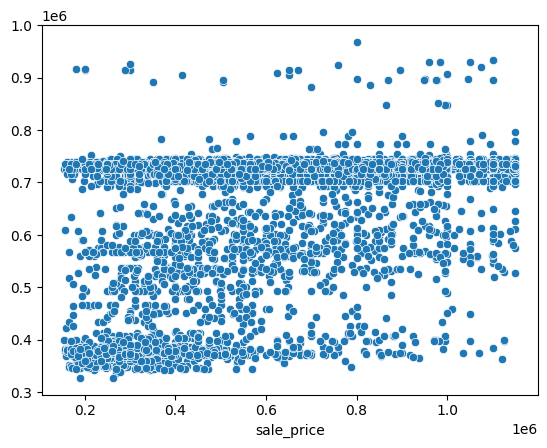

In [ ]:
# If these values follow a line = good predictions
sns.scatterplot(x=y_test, y=predictions)

---

#### Creating a DataFrame to Compare Individual `sale_price` with `error_margin`

Let's create a dataframe we can compare the `sale_price` to the prediction results more easily.

### Testing with Imaginary Values

|Step|Description|
|---|---|
|1| Data Cleaning |
|2| Transformation|
|3| ML Training & Metrics|
|4| <bold style="background:yellow;color:black;">Tester Row Values</bold>|
|5| Personal Analysis |
|6|GUI Application|
|7| Advanced Tasks|


Here, we'll be adding some tester_values and letting the model predict the price for us. We're going to create a dictionary where each feature, or `X`, is a key. We then place imaginary values inside of the key:value pair and use the `.predict` method to give us the result.

In [ ]:
tester_row = {
       'bldgclass_D4' : 1,
       'bldgclass_C6' : 0,
       'numfloors' : 5, 
       'bldgarea' : 1700,
       'lotarea' : 2100,
       'borough_y_MN' : 0,
       'bldgclass_G4' : 0,
       'bldgclass_D1' : 1,
       'bldgclass_D3' : 0,
       'bldgclass_A6' : 0,
       'bldgclass_C7': 0,
       'borough_y_QN': 0,
       'bldgclass_S9': 0,
       'bldgclass_C5': 0,
       'borough_y_BX': 1,
       'bldgclass_F9': 0,
       'bldgclass_K1': 0,
       'bldgclass_G1': 0,
       'bldgclass_F5': 0,
       'bldgclass_O2': 0,
       'bldgclass_O5': 0,
       'bldgclass_O7': 0,
       'bldgclass_D7': 0,
       'bldgclass_D6': 0,
       'bldgclass_A8': 0,
       'bldgclass_E9': 0,
       'bldgclass_G9': 0,
       'bldgclass_M9': 0
}

# Convert to pandas format
tester_row = pd.DataFrame([tester_row])

# Get the output/result from the model
# Based on the user's given new data 
result = lm.predict(tester_row)[0]

print()
print(f"Predicted price for this home:")
print(f"$ {round(float(result), 2)}")
print("----------------------------")

# Well, it's a valid number!


Predicted price for this home:
$ 100230.97
----------------------------


---

### Personal Analysis

<br>

|Step|Description|
|---|---|
|1| Data Cleaning |
|2| Transformation|
|3|ML Training & Metrics|
|4| Tester Row Values|
|5|<bold style="background:yellow;color:black;"> Personal Analysis </bold>|
|6|Model Application|
|7| Advanced Tasks|

<br>
<br>
<br>

In my personal analysis, I'll be performing the following process:

|Step|Description|
|---|---|
|1| Create a dataframe which can easily compare the `predicted_price` with the `sale_price`.|
|2| (I do research here)|
|3| Give some post-research observations.|



#### Creating a Dataframe with `predicted_price` and `error_margin`

Below, we're creating a dataframe that easily lets us check the results for `x_test` and `y_test`. Let's create a dataframe which lets us see everything (the predicted value, the actual value, error margins, and the features in the test data)

In [ ]:
# Adding a column to the dataframe which predicted the price.

case_df = df
case_df['predicted_price'] = lm.predict(X)

# Creating an error margin column for the price for each row.
case_df["error_margin"] = abs(df["sale_price"] - df['predicted_price'])

# Filtering the dataframe to check out the highest error margins, starting with the highest error_margin.
case_df_over_500000 = df[df['error_margin'] > 500000].sort_values(by='error_margin', ascending=False)
case_df_over_500000.head(10)

# Here, we can see some of the extreme cases with high error margins.
# NOTE: `error_margin` and `predicted_price` is at the end of the dataset

,sale_price,lotarea,bldgarea,unitsres,unitstotal,numfloors,building_age,borough_y_BK,borough_y_BX,borough_y_MN,...,bldgclass_O7,bldgclass_O8,bldgclass_S1,bldgclass_S2,bldgclass_S3,bldgclass_S4,bldgclass_S5,bldgclass_S9,predicted_price,error_margin
3482,180000,7587.0,77635.0,16.0,40.0,11.0,105.0,0,0,1,...,0,0,0,0,0,0,0,0,968097.106001,788097.106001
12253,1150000,11750.0,49158.0,39.0,39.0,6.0,99.0,1,0,0,...,0,0,0,0,0,0,0,0,375501.699738,774498.300262
12246,1150000,10300.0,44100.0,33.0,33.0,6.0,100.0,1,0,0,...,0,0,0,0,0,0,0,0,375855.233416,774144.766584
23675,1148000,10000.0,52454.0,43.0,43.0,6.0,93.0,0,0,0,...,0,0,0,0,0,0,0,0,383026.362468,764973.637532
4048,1120000,118122.0,332660.0,330.0,330.0,6.0,73.0,0,0,0,...,0,0,0,0,0,0,0,0,364297.077413,755702.922587
32917,1150000,32400.0,141920.0,146.0,146.0,8.0,76.0,0,0,0,...,0,0,0,0,0,0,0,0,396081.936402,753918.063598
17516,1150000,2573.0,8272.0,8.0,8.0,4.0,105.0,1,0,0,...,0,0,0,0,0,0,0,0,398554.740406,751445.259594
1564,186500,3997.0,15544.0,24.0,24.0,6.0,116.0,0,0,1,...,0,0,0,0,0,0,0,0,924352.384613,737852.384613
20898,1107284,84760.0,225240.0,207.0,208.0,6.0,60.0,0,0,0,...,0,0,0,0,0,0,0,0,371726.230476,735557.769524
20917,180000,1750.0,6275.0,5.0,5.0,5.0,124.0,0,0,1,...,0,0,0,0,0,0,0,0,915308.431708,735308.431708


<h3>Post-Research Observations: </h3>

<div style="border: 3px dashed white; padding: 10px; box-sizing: border-box;">

<i>

I experimented by putting in a new model, `RandomForestRegressor` to see if it would give me improvements.
The results for `RandomForestRegressor` were only marginally better than `LinearRegression`. Here are the results:

</i>

<br>


|Random Forest Regressor Scatterplot (y-test, prediction)| Random Forest Regressor Performance Metrics|
|---|---|
|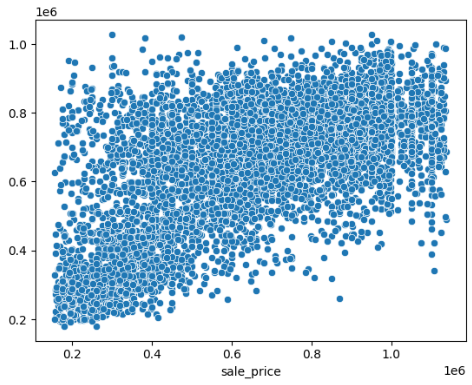|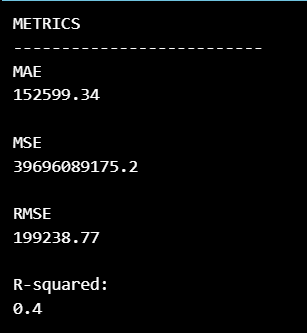|

I've done some research and some work related to WHY the performance metrics are so low with this particular dataset.

<br>
<i>
<strong style='color:orange ; background-color:black;'>
  TLDR: It's a dataset issue.
</strong></i>

<b>Reasoning:</b>

<i>
<b>We're missing a key feature when it comes to NYC housing -- Maintenance contracts.</b>

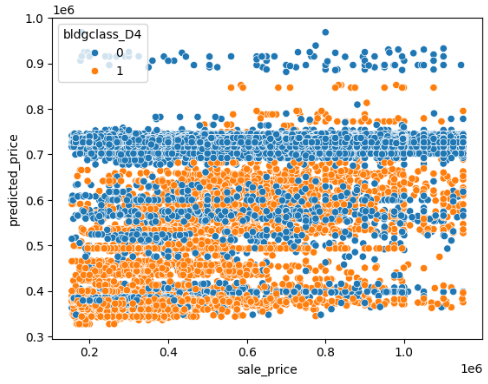

 Just like in Finland,
many homes are part of housing associations or come with a maintenance contract, which affect the price HEAVILY. These maintenance contracts 
correlate negatively with the sales price of the home/apartment (higher maintenance cost, lower home price).
 Look at the example below so you get an idea of what I mean. Assume that these two homes are the same just with different maintenance contracts/costs.
But say that they have different maintenance contracts.

</i>

<b>Example:</b>

|House|House Price| Maintenance Cost/month|
|---|---|---|
|1| 400,000| 1,200|
|2| 1,000,000| 300|

<br>
<i>

`bldgclass_D4` is an apartment co-op building class, which are homes that are notorious for having high variance in these maintenance fees. 

Therefore, since price of the home is heavily correlated by the maintenance cost and since we do not have this `maintenance_costs/mo` in the dataset and
cannot easily retrieve it, the dataset is likely inherently flawed no matter how much optimization I use. Another complication is that this dataset isn't home-prices, but <b>lot </b> prices (commercial and residential), which is likely more complicated because
it means both individual homes and entire apt complexes are in the dataset. Also, that makes the price differences between lots huge.

NOW, if you're wondering "Regarding the maintenance costs, why doesn't this maintenance variance show up on other kaggle datasets?" 

Well that's because this dataset is for NYC house prices. New York City is a cold climate. You don't typically see this much maintenance expense in California unless you're living under an HOA.

<b>Overall Thoughts </b>

I was pretty happy with this result. It was a tough dataset, but I learned quite a bit about selecting the correct features and where/how `LinearRegression` falls short. I am pleased that the predicted vs. y-test scatterplot looks like a line, despite running many features. I think that's a job well done for a first ML notebook.

</i>

<b>Sources:</b> 

<i>
If you'd like to see how I made reached this conclusion:
</i>
<br>
<br>

|Number|Source|
|---|---|
|1|[A forum discussing the maintenance cost & resale price](https://streeteasy.com/talk/discussion/40799-should-i-be-scared-away-by-high-maintenance-fee)
|2|[A paper that not-so-briefly discusses the complexity of the problem](https://arxiv.org/pdf/2007.01171)

</div>


---

### GUI Application

|Step|Description|
|---|---|
|1| Data Cleaning |
|2| Transformation|
|3|ML Training & Metrics|
|4| Tester Row Values|
|5| Personal Analysis|
|6| <bold style="background:yellow;color:black;">GUI Application</bold>|
|7| Advanced Tasks|

In this model application, we'll create a <strong> GUI that allows the user to enter NYC home characteristics and give a predicted lot price</strong>
and parameters for their home and it will spit out a predicted price. We'll be using `gradio` for this application. I chose this app because it has webdev-like features
and we can run it as the output in a jupyter-notebook cell(nice and quick to test.).

### <strong style='color:red ; background-color:black;'>FULL DISCLOSURE: I AM USING AI.</strong>

<div style="border: 3px dashed white; padding: 10px; box-sizing: border-box;">

#### What is AI generated?

_The two lists at the beginning. I couldn't be bothered to write them myself._
<br>


#### LLM:

_ChatGPT 5.0_ 

</div>


In [ ]:
features_list

['bldgclass_D4',
 'bldgclass_C6',
 'numfloors',
 'bldgarea',
 'lotarea',
 'borough_y_MN',
 'bldgclass_G4',
 'bldgclass_D1',
 'bldgclass_D3',
 'bldgclass_A6',
 'bldgclass_C7',
 'borough_y_QN',
 'bldgclass_S9',
 'bldgclass_C5',
 'borough_y_BX',
 'bldgclass_F9',
 'bldgclass_K1',
 'bldgclass_G1',
 'bldgclass_F5',
 'bldgclass_O2',
 'bldgclass_O5',
 'bldgclass_O7',
 'bldgclass_D7',
 'bldgclass_D6',
 'bldgclass_A8',
 'bldgclass_E9',
 'bldgclass_G9',
 'bldgclass_M9']

In [ ]:
import gradio as gr


# We use these to create key-value pairs with conditional logic. 
bldg_classes = ['A0', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A8', 'A9',
            'B1', 'B2', 'B3', 'B9','C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'D0', 
            'D1', 'D3', 'D4', 'D6', 'D7', 'E1', 'E9','F4', 'F5', 'F9','G1', 'G2', 'G4', 
            'G8', 'G9', 'K1', 'K2', 'K4', 'K7', 'M1', 'M9', 'O2', 'O5', 'O7', 'O8', 'S1',
            'S2', 'S3', 'S4', 'S5', 'S9']

boroughs = ["BK", "BX", "MN", "QN", "SI"]

# This function interprets the values submitted from the user in the gradio app and predicts the result.
def predict(borough, bldg_class, lotarea, bldgarea, 
    unitsres, unitstotal, numfloors, building_age):

    # First, we're going to create a dict. Notice it's incomplete! See the next step.
    tester_row = {
    'lotarea': lotarea, 'bldgarea': bldgarea,
    'unitsres': unitsres, 'unitstotal': unitstotal,
    'numfloors': numfloors, 'building_age': building_age,
    }

    # Next, this loop will add all the boroughs in the `tester_row` dictionary...

    # If the user-selected borough matches the bourough iteration in the list...
    # give a value of 1. Otherwise, give the value 0.
    # Then, add it as a key:value pair in the `tester_row` dict.
    for b in boroughs:
        borough_key = f"borough_y_{b}"

        if b == borough:
            tester_row[borough_key] = 1
        else:
            tester_row[borough_key] = 0

    # Same as above, except classes edition, baby!
    for c in bldg_classes:
        bldgclass_key = f"bldgclass_{c}"

        if c == bldg_class:
            tester_row[bldgclass_key] = 1
        else:
            tester_row[bldgclass_key] = 0
  
    # Transform the dict into a dataframe, and predict the user's output.
    tester_row = pd.DataFrame([tester_row])
    result = lm.predict(tester_row)[0]
    result = result.round(2)
    
    return result

# Use Gradio Blocks to create a GUI! This should show up in the output cell.
# NOTE: Click the `local URL` link for it to appear in your web-browser, if you prefer. 

with gr.Blocks() as house_lot_prediction:

    gr.Markdown("## NYC Home Price Predictor")
    gr.Markdown("### Enter Property Details")

    # Input options
    select_borough = gr.Dropdown(choices=boroughs, label="Which Borough do you live in?")
    select_class = gr.Dropdown(choices=bldg_classes, label="What building class does your lot have?")
    select_lotarea = gr.Number(label="How big is your plot of land? (freedom units please)")
    select_bldgarea = gr.Number(label="How much building area is on your plot of land? (freedom units please)")
    select_numfloors = gr.Slider(label="What's the maximum number of floors on your plot of land?", minimum=1, maximum=104)
    select_building_age =gr.Slider(label="How old, on average, is your buildings?", minimum=0, maximum=250)

    gr.Markdown("### Prediction")

    # Prediction output and submit button
    outputs = gr.Number(label="Home Price")
    submit = gr.Button("Predict Price")

    # Click action functionality
    submit.click(
        fn=predict,
        inputs=[
            select_borough, select_class, select_lotarea,
            select_bldgarea,  select_numfloors, select_building_age
            ],
        outputs=outputs
    )

house_lot_prediction.launch()

# If you don't see the submit button, keep scrolling. It's there!

c:\Users\OWNER\Intro_ML\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\OWNER\Intro_ML\.venv\Lib\site-packages\gradio\utils.py:1173: UserWarning: Expected 8 arguments for function <function predict at 0x000001FF79186340>, received 6.
  warnings.warn(
c:\Users\OWNER\Intro_ML\.venv\Lib\site-packages\gradio\utils.py:1177: UserWarning: Expected at least 8 arguments for function <function predict at 0x000001FF79186340>, received 6.
  warnings.warn(


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


---

## Advanced Tasks

|Step|Description|
|---|---|
|1| Data Cleaning |
|2| Transformation|
|3|ML Training & Metrics|
|4| Tester Row Values|
|5| Personal Analysis|
|6| GUI Application|
|7| <bold style="background:yellow;color:black;">Advanced Tasks </bold>|

<br>
<br>

#### Advanced Task Contents


|Task|Description|
|---|---|
|1|<bold style="background:yellow;color:black;"> Experiment with polynomial and curve fitting features of `scikit-learn` with any dataset. Explain your findings in your Jupyter notebook, and analyze how useful they are.</bold>|
|2|Write down the multiple linear regression formula of your model by using the `intercept-` and `coeff–` variables in your model `–object`.|
|3|You can also consider using other regressors like `CatBoostRegressor` which allows you to use other types of data than numbers without transformations. Write down your experiences with this regressor.|

<br>
<br>

### Adv. Task 1 -- Polynomial, Curve-fitting feature experimentation

### _[Link to Notebook](ex1_adv1.ipynb)_

<br>

### Adv. Task 2 -- Print the Poly-Linear Regression



|Task|Description|
|---|---|
|1|Experiment with polynomial and curve fitting features of `scikit-learn` with any dataset. Explain your findings in your Jupyter notebook, and analyze how useful they are.|
|2|<bold style="background:yellow;color:black;"> Write down the multiple linear regression formula of your model by using the `intercept-` and `coeff–` variables in your model `–object`.</bold>|
|3|You can also consider using other regressors like `CatBoostRegressor` which allows you to use other types of data than numbers without transformations. Write down your experiences with this regressor.|

This shouldn't be terribly hard, especially since the intercept and coefficient are literally given as 
`intercept-` and `coeff-`. The only REAL issue is that we have so many features that we'll need to creative with naming the variables.

In [ ]:
# The strategy will be to append a string with it's coefficients.
# IE: "Jere" + "my" = "Jeremy"

# First, we'll turn the coefficients into a list.
# This makes it easier to iterate over.
coefs_list = coefs.tolist()

# Second, we create a number translator for subscripts.
sub = str.maketrans("0123456789", "₀₁₂₃₄₅₆₇₈₉")

# Third, we create the string variable, startying with ` y =`
regression_string = "y = "

# Fourth, initiate a loop which will append to the string above.
# The `enumerate` in the loop will let me call the VALUE and the INDEX.
# The index will be used to generate new variable names.
# The value, `coef`, will let us call the weight.
# IE: WeightX₁ + WeightX₂ WeightX₃ 
for  index, coef in enumerate(coefs_list):
    index += 1
    index = str(index).translate(sub)
    coef = round(coef,2)

    regression_string += f"{coef}x{index} + " 

regression_string += str(intercept)
print(regression_string)


y = -386351.73x₁ + -346825.9x₂ + 9704.45x₃ + -0.08x₄ + 0.03x₅ + 160091.47x₆ + -369035.47x₇ + -244568.89x₈ + -390999.93x₉ + -241275.55x₁₀ + -222900.59x₁₁ + 7838.03x₁₂ + -170385.16x₁₃ + -177885.49x₁₄ + -24436.31x₁₅ + -370891.98x₁₆ + -116763.54x₁₇ + -162461.12x₁₈ + -98781.4x₁₉ + -151871.55x₂₀ + -137514.12x₂₁ + -117478.38x₂₂ + -299674.72x₂₃ + -306565.33x₂₄ + -239782.43x₂₅ + -83562.43x₂₆ + -41413.71x₂₇ + -106088.01x₂₈ + 707134.8107830948


### Adv. Task 3 -- Using `CatBoostRegressor`

### _[Link to Notebook](ex1_adv3.ipynb)_